In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import linregress

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
# Load datasets

nav = pd.read_csv("../data/raw/02_nav_history.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

print("Datasets loaded successfully")

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/02_nav_history.csv'

In [3]:
import os

print(os.getcwd())

C:\Users\SAI VARDHAN


In [4]:
import os

os.chdir(r"D:\mutual_fund_project")

print(os.getcwd())

D:\mutual_fund_project


In [5]:
nav = pd.read_csv("data/raw/02_nav_history.csv")
performance = pd.read_csv("data/raw/07_scheme_performance.csv")

print("Datasets loaded successfully")


Datasets loaded successfully


In [6]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [7]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [8]:
nav.describe()

,amfi_code,nav
count,46000.000000,46000.000000
mean,120247.000000,269.570265
std,14352.317221,577.187060
min,100016.000000,26.136600
25%,118632.750000,69.170425
50%,119551.500000,122.732150
75%,120842.250000,260.338675
max,149324.000000,4268.549700


In [9]:
# Convert date column to datetime

nav["date"] = pd.to_datetime(nav["date"])

print(nav.dtypes)


amfi_code             int64
date         datetime64[ns]
nav                 float64
dtype: object


In [10]:
# Sort data by fund and date

nav = nav.sort_values(by=["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [11]:
# Calculate Daily Returns

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [12]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

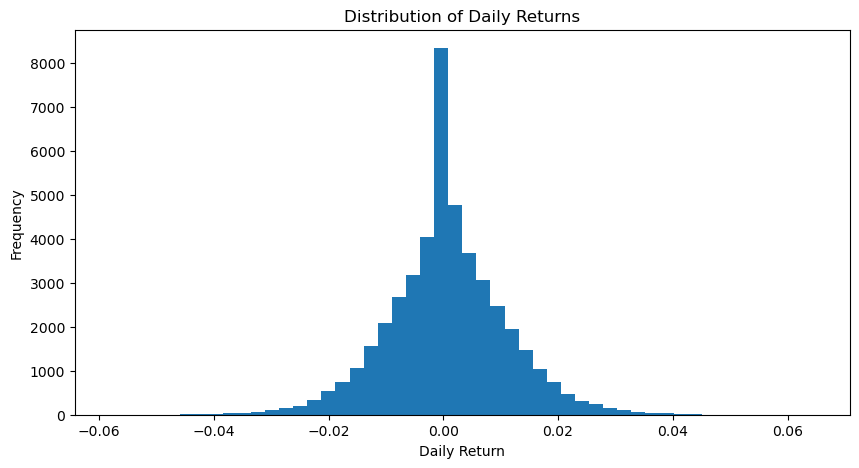

In [13]:
plt.figure(figsize=(10,5))

plt.hist(nav["daily_return"].dropna(), bins=50)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [14]:
# Check date range

print("Start Date:", nav["date"].min())
print("End Date:", nav["date"].max())

Start Date: 2022-01-03 00:00:00
End Date: 2026-05-29 00:00:00


In [15]:
# First and Last NAV for each fund

fund_summary = nav.groupby("amfi_code").agg(
    start_date=("date", "min"),
    end_date=("date", "max"),
    start_nav=("nav", "first"),
    end_nav=("nav", "last")
)

fund_summary.head()

,start_date,end_date,start_nav,end_nav
amfi_code,,,,
100016,2022-01-03,2026-05-29,520.4608,583.6113
100025,2022-01-03,2026-05-29,26.3169,31.8843
100033,2022-01-03,2026-05-29,107.3758,342.0072
101206,2022-01-03,2026-05-29,305.0996,773.2939
101207,2022-01-03,2026-05-29,38.5736,53.9836


In [16]:
# Calculate investment period in years

fund_summary["years"] = (
    (fund_summary["end_date"] - fund_summary["start_date"]).dt.days
) / 365

fund_summary.head()



,start_date,end_date,start_nav,end_nav,years
amfi_code,,,,,
100016,2022-01-03,2026-05-29,520.4608,583.6113,4.40274
100025,2022-01-03,2026-05-29,26.3169,31.8843,4.40274
100033,2022-01-03,2026-05-29,107.3758,342.0072,4.40274
101206,2022-01-03,2026-05-29,305.0996,773.2939,4.40274
101207,2022-01-03,2026-05-29,38.5736,53.9836,4.40274


In [17]:
# Calculate CAGR

fund_summary["CAGR"] = (
    (fund_summary["end_nav"] / fund_summary["start_nav"])
    ** (1 / fund_summary["years"])
) - 1

fund_summary.head()

,start_date,end_date,start_nav,end_nav,years,CAGR
amfi_code,,,,,,
100016,2022-01-03,2026-05-29,520.4608,583.6113,4.40274,0.026352
100025,2022-01-03,2026-05-29,26.3169,31.8843,4.40274,0.044551
100033,2022-01-03,2026-05-29,107.3758,342.0072,4.40274,0.300997
101206,2022-01-03,2026-05-29,305.0996,773.2939,4.40274,0.235205
101207,2022-01-03,2026-05-29,38.5736,53.9836,4.40274,0.079331


In [18]:
# Convert CAGR to percentage

fund_summary["CAGR (%)"] = fund_summary["CAGR"] * 100

fund_summary[["start_nav", "end_nav", "years", "CAGR (%)"]].head()

,start_nav,end_nav,years,CAGR (%)
amfi_code,,,,
100016,520.4608,583.6113,4.40274,2.635246
100025,26.3169,31.8843,4.40274,4.455091
100033,107.3758,342.0072,4.40274,30.099704
101206,305.0996,773.2939,4.40274,23.520489
101207,38.5736,53.9836,4.40274,7.933121


In [19]:
# Check available years of data

total_years = (nav["date"].max() - nav["date"].min()).days / 365

print("Available Years:", round(total_years,2))

Available Years: 4.4


In [20]:
# Latest date in the dataset
latest_date = nav["date"].max()

# Date approximately one year before
one_year_date = latest_date - pd.DateOffset(years=1)

print("Latest Date :", latest_date)
print("1 Year Back :", one_year_date)

Latest Date : 2026-05-29 00:00:00
1 Year Back : 2025-05-29 00:00:00


In [21]:
# Latest NAV for each fund
latest_nav = nav[nav["date"] == latest_date][["amfi_code", "nav"]]
latest_nav = latest_nav.rename(columns={"nav": "latest_nav"})

# NAV one year back for each fund
one_year_nav = nav[nav["date"] == one_year_date][["amfi_code", "nav"]]
one_year_nav = one_year_nav.rename(columns={"nav": "nav_1yr"})

# Merge both tables
cagr_1yr = latest_nav.merge(one_year_nav, on="amfi_code")

cagr_1yr.head()

,amfi_code,latest_nav,nav_1yr
0,100016,583.6113,596.8877
1,100025,31.8843,30.7452
2,100033,342.0072,223.1951
3,101206,773.2939,522.7639
4,101207,53.9836,71.0180


In [22]:
# Calculate 1-Year CAGR

cagr_1yr["CAGR_1yr"] = (
    (cagr_1yr["latest_nav"] / cagr_1yr["nav_1yr"])
    ** (1/1)
) - 1

# Convert to Percentage

cagr_1yr["CAGR_1yr (%)"] = cagr_1yr["CAGR_1yr"] * 100

cagr_1yr.head()

,amfi_code,latest_nav,nav_1yr,CAGR_1yr,CAGR_1yr (%)
0,100016,583.6113,596.8877,-0.022243,-2.224271
1,100025,31.8843,30.7452,0.037050,3.704969
2,100033,342.0072,223.1951,0.532324,53.232396
3,101206,773.2939,522.7639,0.479241,47.924120
4,101207,53.9836,71.0180,-0.239860,-23.986032


In [23]:
# Date approximately 3 years before

three_year_date = latest_date - pd.DateOffset(years=3)

print("Latest Date :", latest_date)
print("3 Years Back:", three_year_date)

Latest Date : 2026-05-29 00:00:00
3 Years Back: 2023-05-29 00:00:00


In [24]:
# Latest NAV
latest_nav = nav[nav["date"] == latest_date][["amfi_code", "nav"]]
latest_nav = latest_nav.rename(columns={"nav": "latest_nav"})

# NAV from 3 years ago
three_year_nav = nav[nav["date"] == three_year_date][["amfi_code", "nav"]]
three_year_nav = three_year_nav.rename(columns={"nav": "nav_3yr"})

# Merge
cagr_3yr = latest_nav.merge(three_year_nav, on="amfi_code")

cagr_3yr.head()

,amfi_code,latest_nav,nav_3yr
0,100016,583.6113,561.5519
1,100025,31.8843,28.4135
2,100033,342.0072,147.2155
3,101206,773.2939,360.4971
4,101207,53.9836,61.3081


In [25]:
# Calculate 3-Year CAGR

cagr_3yr["CAGR_3yr"] = (
    (cagr_3yr["latest_nav"] / cagr_3yr["nav_3yr"])
    ** (1 / 3)
) - 1

# Convert to Percentage

cagr_3yr["CAGR_3yr (%)"] = cagr_3yr["CAGR_3yr"] * 100

cagr_3yr.head()

,amfi_code,latest_nav,nav_3yr,CAGR_3yr,CAGR_3yr (%)
0,100016,583.6113,561.5519,0.012926,1.292649
1,100025,31.8843,28.4135,0.039164,3.916390
2,100033,342.0072,147.2155,0.324425,32.442459
3,101206,773.2939,360.4971,0.289677,28.967695
4,101207,53.9836,61.3081,-0.041524,-4.152381


In [26]:
# Merge all CAGR tables

cagr_table = fund_summary[["CAGR (%)"]].merge(
    cagr_1yr[["amfi_code", "CAGR_1yr (%)"]],
    left_index=True,
    right_on="amfi_code"
)

cagr_table = cagr_table.merge(
    cagr_3yr[["amfi_code", "CAGR_3yr (%)"]],
    on="amfi_code"
)

cagr_table.head()

,CAGR (%),amfi_code,CAGR_1yr (%),CAGR_3yr (%)
0,2.635246,100016,-2.224271,1.292649
1,4.455091,100025,3.704969,3.916390
2,30.099704,100033,53.232396,32.442459
3,23.520489,101206,47.924120,28.967695
4,7.933121,101207,-23.986032,-4.152381


In [27]:
# Arrange columns neatly

cagr_table = cagr_table[
    [
        "amfi_code",
        "CAGR_1yr (%)",
        "CAGR_3yr (%)",
        "CAGR (%)"
    ]
]

cagr_table.rename(columns={
    "CAGR (%)": "Overall CAGR (%)"
}, inplace=True)

cagr_table.head()

,amfi_code,CAGR_1yr (%),CAGR_3yr (%),Overall CAGR (%)
0,100016,-2.224271,1.292649,2.635246
1,100025,3.704969,3.916390,4.455091
2,100033,53.232396,32.442459,30.099704
3,101206,47.924120,28.967695,23.520489
4,101207,-23.986032,-4.152381,7.933121


In [28]:
cagr_table["CAGR_5yr (%)"] = np.nan

In [29]:
cagr_table["CAGR_5yr (%)"] = "Not Available"

In [30]:
cagr_table.to_csv(
    "reports/cagr_comparison.csv",
    index=False
)

print("CAGR comparison table saved successfully.")

CAGR comparison table saved successfully.


# Task 3 – Sharpe Ratio Analysis

**Objective:**

Compute the Sharpe Ratio for all 40 mutual fund schemes using a 6.5% annual risk-free rate and rank the funds based on risk-adjusted returns.

In [32]:
# Annual Risk-Free Rate (RBI Repo Rate Proxy)

risk_free_rate = 0.065

# Daily Risk-Free Rate
daily_rf = risk_free_rate / 252

print("Annual Risk-Free Rate :", risk_free_rate)
print("Daily Risk-Free Rate :", daily_rf)

Annual Risk-Free Rate : 0.065
Daily Risk-Free Rate : 0.00025793650793650796


In [33]:
# Mean Daily Return for each Fund

mean_returns = (
    nav.groupby("amfi_code")["daily_return"]
       .mean()
       .reset_index()
)

mean_returns.rename(
    columns={"daily_return": "mean_daily_return"},
    inplace=True
)

mean_returns.head()

,amfi_code,mean_daily_return
0,100016,0.000142
1,100025,0.000170
2,100033,0.001080
3,101206,0.000852
4,101207,0.000424


In [34]:
# Standard Deviation of Daily Returns

std_returns = (
    nav.groupby("amfi_code")["daily_return"]
       .std()
       .reset_index()
)

std_returns.rename(
    columns={"daily_return": "std_daily_return"},
    inplace=True
)

std_returns.head()

,amfi_code,std_daily_return
0,100016,0.009164
1,100025,0.002460
2,100033,0.011929
3,101206,0.009177
4,101207,0.016251


In [35]:
sharpe_df.to_csv(
    "reports/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio Analysis Completed Successfully!")

NameError: name 'sharpe_df' is not defined

In [36]:
# Merge mean and standard deviation

sharpe_df = mean_returns.merge(
    std_returns,
    on="amfi_code"
)

sharpe_df.head()

,amfi_code,mean_daily_return,std_daily_return
0,100016,0.000142,0.009164
1,100025,0.000170,0.002460
2,100033,0.001080,0.011929
3,101206,0.000852,0.009177
4,101207,0.000424,0.016251


In [37]:
sharpe_df.to_csv(
    "reports/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio Analysis Completed Successfully!")

Sharpe Ratio Analysis Completed Successfully!


In [38]:
sharpe_df.head(10)

,amfi_code,mean_daily_return,std_daily_return
0,100016,0.000142,0.009164
1,100025,0.000170,0.002460
2,100033,0.001080,0.011929
3,101206,0.000852,0.009177
4,101207,0.000424,0.016251
5,101208,0.000242,0.000319
6,102885,0.000674,0.008086
7,102886,0.000110,0.011424
8,102887,0.000645,0.009927
9,118632,0.000865,0.008913


In [39]:
# Calculate Sharpe Ratio

sharpe_df["Sharpe Ratio"] = (
    (sharpe_df["mean_daily_return"] - daily_rf)
    / sharpe_df["std_daily_return"]
) * np.sqrt(252)

sharpe_df.head()

,amfi_code,mean_daily_return,std_daily_return,Sharpe Ratio
0,100016,0.000142,0.009164,-0.201517
1,100025,0.000170,0.002460,-0.567095
2,100033,0.001080,0.011929,1.093699
3,101206,0.000852,0.009177,1.027213
4,101207,0.000424,0.016251,0.162661


In [40]:
# Rank funds

sharpe_df = sharpe_df.sort_values(
    by="Sharpe Ratio",
    ascending=False
)

sharpe_df["Rank"] = range(1, len(sharpe_df) + 1)

sharpe_df.head(10)

,amfi_code,mean_daily_return,std_daily_return,Sharpe Ratio,Rank
34,148567,0.001074,0.008941,1.448291,1
30,120843,0.001082,0.010008,1.306744,2
36,148569,0.001124,0.011134,1.234930,3
19,119551,0.000917,0.008656,1.208267,4
25,120505,0.001161,0.012152,1.180101,5
38,149323,0.001055,0.011179,1.132122,6
2,100033,0.001080,0.011929,1.093699,7
9,118632,0.000865,0.008913,1.081659,8
3,101206,0.000852,0.009177,1.027213,9
24,120504,0.000843,0.009048,1.026524,10


# Task 4 – Sortino Ratio Analysis

**Objective:**

Compute the Sortino Ratio for all mutual fund schemes using the annual risk-free rate of 6.5%. Unlike the Sharpe Ratio, the Sortino Ratio considers only downside volatility (negative daily returns).

In [41]:
# Filter only negative daily returns

downside_returns = nav[nav["daily_return"] < 0]

downside_returns.head()

,amfi_code,date,nav,daily_return
5751,100016,2022-01-04,515.0971,-0.010306
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5757,100016,2022-01-12,512.3195,-0.002404


In [42]:
# Downside Standard Deviation for each Fund

downside_std = (
    downside_returns
    .groupby("amfi_code")["daily_return"]
    .std()
    .reset_index()
)

downside_std.rename(
    columns={"daily_return": "downside_std"},
    inplace=True
)

downside_std.head()

,amfi_code,downside_std
0,100016,0.005261
1,100025,0.001481
2,100033,0.007133
3,101206,0.005238
4,101207,0.009555


In [43]:
# Merge Mean Return with Downside Standard Deviation

sortino_df = mean_returns.merge(
    downside_std,
    on="amfi_code"
)

sortino_df.head()

,amfi_code,mean_daily_return,downside_std
0,100016,0.000142,0.005261
1,100025,0.000170,0.001481
2,100033,0.001080,0.007133
3,101206,0.000852,0.005238
4,101207,0.000424,0.009555


In [44]:
# Calculate Sortino Ratio

sortino_df["Sortino Ratio"] = (
    (sortino_df["mean_daily_return"] - daily_rf)
    / sortino_df["downside_std"]
) * np.sqrt(252)

sortino_df.head()

,amfi_code,mean_daily_return,downside_std,Sortino Ratio
0,100016,0.000142,0.005261,-0.351047
1,100025,0.000170,0.001481,-0.941821
2,100033,0.001080,0.007133,1.829134
3,101206,0.000852,0.005238,1.799563
4,101207,0.000424,0.009555,0.276644


In [45]:
# Rank funds based on Sortino Ratio

sortino_df = sortino_df.sort_values(
    by="Sortino Ratio",
    ascending=False
)

sortino_df["Rank"] = range(1, len(sortino_df) + 1)

sortino_df.head(10)

,amfi_code,mean_daily_return,downside_std,Sortino Ratio,Rank
34,148567,0.001074,0.005428,2.385644,1
30,120843,0.001082,0.005531,2.364320,2
36,148569,0.001124,0.006404,2.146914,3
19,119551,0.000917,0.004887,2.140267,4
25,120505,0.001161,0.007067,2.029353,5
38,149323,0.001055,0.006750,1.875101,6
9,118632,0.000865,0.005211,1.850133,7
2,100033,0.001080,0.007133,1.829134,8
24,120504,0.000843,0.005145,1.805294,9
3,101206,0.000852,0.005238,1.799563,10


In [46]:
sortino_df.to_csv(
    "reports/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio Analysis Completed Successfully!")

Sortino Ratio Analysis Completed Successfully!


In [47]:
sortino_df.head(10)

,amfi_code,mean_daily_return,downside_std,Sortino Ratio,Rank
34,148567,0.001074,0.005428,2.385644,1
30,120843,0.001082,0.005531,2.364320,2
36,148569,0.001124,0.006404,2.146914,3
19,119551,0.000917,0.004887,2.140267,4
25,120505,0.001161,0.007067,2.029353,5
38,149323,0.001055,0.006750,1.875101,6
9,118632,0.000865,0.005211,1.850133,7
2,100033,0.001080,0.007133,1.829134,8
24,120504,0.000843,0.005145,1.805294,9
3,101206,0.000852,0.005238,1.799563,10



# Task 5 – Alpha & Beta Analysis

**Objective:**

Calculate Alpha and Beta for all mutual fund schemes using Nifty 100 benchmark returns. Beta is calculated using linear regression, while Alpha is annualized by multiplying the regression intercept by 252 trading days.

In [48]:
# Load Benchmark Dataset

benchmark = pd.read_csv("data/raw/10_benchmark_indices.csv")

print("Benchmark dataset loaded successfully")
benchmark.head()

Benchmark dataset loaded successfully


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [49]:
benchmark.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   object 
 1   index_name   8050 non-null   object 
 2   close_value  8050 non-null   float64
dtypes: float64(1), object(2)
memory usage: 188.8+ KB


In [50]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [51]:
# Keep only NIFTY100 data

benchmark = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

benchmark.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [52]:
# Convert date to datetime

benchmark["date"] = pd.to_datetime(benchmark["date"])

# Sort

benchmark = benchmark.sort_values("date")

benchmark.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [53]:
# Benchmark Daily Return

benchmark["benchmark_return"] = benchmark["close_value"].pct_change()

benchmark.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [54]:
benchmark = benchmark.dropna()

benchmark.head()

,date,index_name,close_value,benchmark_return
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150
1155,2022-01-10,NIFTY100,17516.51,-0.008351


In [55]:
benchmark.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1149 entries, 1151 to 2299
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              1149 non-null   datetime64[ns]
 1   index_name        1149 non-null   object        
 2   close_value       1149 non-null   float64       
 3   benchmark_return  1149 non-null   float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 44.9+ KB


In [56]:
benchmark.head()

,date,index_name,close_value,benchmark_return
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150
1155,2022-01-10,NIFTY100,17516.51,-0.008351


In [57]:
benchmark.head()

,date,index_name,close_value,benchmark_return
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150
1155,2022-01-10,NIFTY100,17516.51,-0.008351


In [58]:
# Calculate Alpha & Beta for each fund

alpha_beta_results = []

for fund in merged_returns["amfi_code"].unique():

    fund_data = merged_returns[
        merged_returns["amfi_code"] == fund
    ]

    slope, intercept, r_value, p_value, std_err = linregress(
        fund_data["benchmark_return"],
        fund_data["daily_return"]
    )

    alpha_beta_results.append({
        "amfi_code": fund,
        "Beta": slope,
        "Alpha": intercept * 252
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df.head()

NameError: name 'merged_returns' is not defined

In [59]:
# Merge fund returns with benchmark returns

merged_returns = nav.merge(
    benchmark[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

print("Merged Successfully!")
merged_returns.head()

Merged Successfully!


,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-04,515.0971,-0.010306,-0.013540
1,100016,2022-01-05,521.7239,0.012865,0.004003
2,100016,2022-01-06,515.7880,-0.011377,-0.002935
3,100016,2022-01-07,515.1639,-0.001210,0.006150
4,100016,2022-01-10,510.7136,-0.008639,-0.008351


In [60]:
merged_returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45960 entries, 0 to 45959
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   amfi_code         45960 non-null  int64         
 1   date              45960 non-null  datetime64[ns]
 2   nav               45960 non-null  float64       
 3   daily_return      45960 non-null  float64       
 4   benchmark_return  45960 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 1.8 MB


In [61]:
# Calculate Alpha & Beta

alpha_beta_results = []

for fund in merged_returns["amfi_code"].unique():

    fund_data = merged_returns[
        merged_returns["amfi_code"] == fund
    ].dropna(subset=["daily_return", "benchmark_return"])

    slope, intercept, r_value, p_value, std_err = linregress(
        fund_data["benchmark_return"],
        fund_data["daily_return"]
    )

    alpha_beta_results.append({
        "amfi_code": fund,
        "Beta": slope,
        "Alpha": intercept * 252
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df.head()# Calculate Alpha & Beta

alpha_beta_results = []

for fund in merged_returns["amfi_code"].unique():

    fund_data = merged_returns[
        merged_returns["amfi_code"] == fund
    ].dropna(subset=["daily_return", "benchmark_return"])

    slope, intercept, r_value, p_value, std_err = linregress(
        fund_data["benchmark_return"],
        fund_data["daily_return"]
    )

    alpha_beta_results.append({
        "amfi_code": fund,
        "Beta": slope,
        "Alpha": intercept * 252
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df.head()

,amfi_code,Beta,Alpha
0,100016,-0.058268,0.037476
1,100025,0.001158,0.042818
2,100033,0.005104,0.271954
3,101206,0.021086,0.213998
4,101207,-0.065289,0.108971


In [62]:
.dropna(subset=["daily_return", "benchmark_return"])

SyntaxError: invalid syntax (2465266215.py, line 1)

In [63]:
merged_returns.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-04,515.0971,-0.010306,-0.013540
1,100016,2022-01-05,521.7239,0.012865,0.004003
2,100016,2022-01-06,515.7880,-0.011377,-0.002935
3,100016,2022-01-07,515.1639,-0.001210,0.006150
4,100016,2022-01-10,510.7136,-0.008639,-0.008351


In [64]:
from scipy.stats import linregress

# Calculate Alpha & Beta
alpha_beta_results = []

for fund in merged_returns["amfi_code"].unique():

    # Data for one fund
    fund_data = merged_returns[
        merged_returns["amfi_code"] == fund
    ].dropna(subset=["daily_return", "benchmark_return"])

    # Linear Regression
    slope, intercept, r_value, p_value, std_err = linregress(
        fund_data["benchmark_return"],
        fund_data["daily_return"]
    )

    alpha_beta_results.append({
        "amfi_code": fund,
        "Beta": slope,
        "Alpha": intercept * 252
    })

# Create DataFrame
alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df.head()

,amfi_code,Beta,Alpha
0,100016,-0.058268,0.037476
1,100025,0.001158,0.042818
2,100033,0.005104,0.271954
3,101206,0.021086,0.213998
4,101207,-0.065289,0.108971


In [65]:
# Rank funds by Alpha

alpha_beta_df = alpha_beta_df.sort_values(
    by="Alpha",
    ascending=False
)

alpha_beta_df["Rank"] = range(1, len(alpha_beta_df) + 1)

alpha_beta_df.head(10)

,amfi_code,Beta,Alpha,Rank
21,119598,-0.023196,0.303370,1
39,149324,0.011455,0.300579,2
25,120505,0.000549,0.292636,3
36,148569,0.018134,0.282704,4
30,120843,-0.022830,0.273305,5
2,100033,0.005104,0.271954,6
34,148567,0.023684,0.269838,7
38,149323,-0.002523,0.265986,8
16,119094,-0.066265,0.260767,9
19,119551,-0.031751,0.232010,10


In [66]:
alpha_beta_df.to_csv(
    "reports/alpha_beta.csv",
    index=False
)

print("Alpha & Beta Analysis Completed Successfully!")

Alpha & Beta Analysis Completed Successfully!


In [67]:
alpha_beta_df.head(10)

,amfi_code,Beta,Alpha,Rank
21,119598,-0.023196,0.303370,1
39,149324,0.011455,0.300579,2
25,120505,0.000549,0.292636,3
36,148569,0.018134,0.282704,4
30,120843,-0.022830,0.273305,5
2,100033,0.005104,0.271954,6
34,148567,0.023684,0.269838,7
38,149323,-0.002523,0.265986,8
16,119094,-0.066265,0.260767,9
19,119551,-0.031751,0.232010,10


# Task 6 – Maximum Drawdown Analysis

**Objective:**

Calculate the Maximum Drawdown (MDD) for each mutual fund by comparing the current NAV with its historical running maximum. Identify the worst drawdown value for every fund.

In [68]:
# Running Maximum NAV

nav["running_max"] = (
    nav.groupby("amfi_code")["nav"]
       .cummax()
)

nav.head()

,amfi_code,date,nav,daily_return,running_max
5750,100016,2022-01-03,520.4608,NaN,520.4608
5751,100016,2022-01-04,515.0971,-0.010306,520.4608
5752,100016,2022-01-05,521.7239,0.012865,521.7239
5753,100016,2022-01-06,515.7880,-0.011377,521.7239
5754,100016,2022-01-07,515.1639,-0.001210,521.7239


In [69]:
# Drawdown

nav["drawdown"] = (
    nav["nav"] / nav["running_max"]
) - 1

nav.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
5750,100016,2022-01-03,520.4608,NaN,520.4608,0.000000
5751,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306
5752,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000
5753,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574


In [70]:
# Maximum Drawdown for each fund

max_drawdown = (
    nav.groupby("amfi_code")["drawdown"]
       .min()
       .reset_index()
)

max_drawdown.rename(
    columns={"drawdown": "Maximum Drawdown"},
    inplace=True
)

max_drawdown.head()

,amfi_code,Maximum Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [71]:
max_drawdown.head()

,amfi_code,Maximum Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [72]:
# Worst drawdown date for each fund

worst_drawdown_dates = (
    nav.loc[
        nav.groupby("amfi_code")["drawdown"].idxmin(),
        ["amfi_code", "date", "drawdown"]
    ]
)

worst_drawdown_dates.rename(
    columns={
        "date": "Worst Drawdown Date",
        "drawdown": "Maximum Drawdown"
    },
    inplace=True
)

worst_drawdown_dates.head()

,amfi_code,Worst Drawdown Date,Maximum Drawdown
5933,100016,2022-09-15,-0.247344
10759,100025,2023-07-28,-0.043083
8143,100033,2022-05-12,-0.162172
32592,101206,2023-07-05,-0.112916
34485,101207,2026-05-11,-0.354469


In [73]:
# Merge maximum drawdown with dates

max_drawdown_df = max_drawdown.merge(
    worst_drawdown_dates[["amfi_code", "Worst Drawdown Date"]],
    on="amfi_code"
)

max_drawdown_df.head()

,amfi_code,Maximum Drawdown,Worst Drawdown Date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [74]:
max_drawdown_df.to_csv(
    "reports/max_drawdown.csv",
    index=False
)

print("Maximum Drawdown Analysis Completed Successfully!")

Maximum Drawdown Analysis Completed Successfully!


In [75]:
max_drawdown_df.head()

,amfi_code,Maximum Drawdown,Worst Drawdown Date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [76]:
performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [77]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


# Task 7 – Fund Scorecard (0–100)

**Objective:**

Build a composite Fund Scorecard using weighted rankings based on:
- 30% × 3-Year Return Rank
- 25% × Sharpe Ratio Rank
- 20% × Alpha Rank
- 15% × Expense Ratio Rank (Inverse)
- 10% × Maximum Drawdown Rank (Inverse)

In [78]:
scorecard = performance[
    ["amfi_code", "scheme_name", "return_3yr_pct", "expense_ratio_pct"]
].copy()

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77


In [79]:
scorecard = scorecard.merge(
    sharpe_df[["amfi_code", "Sharpe Ratio"]],
    on="amfi_code"
)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe Ratio
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575


In [80]:
scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "Alpha"]],
    on="amfi_code"
)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe Ratio,Alpha
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267,0.232010
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279,0.198686
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187,0.048824
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209


In [81]:
scorecard = scorecard.merge(
    max_drawdown_df[["amfi_code", "Maximum Drawdown"]],
    on="amfi_code"
)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe Ratio,Alpha,Maximum Drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267,0.232010,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279,0.198686,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187,0.048824,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209,-0.043287


In [82]:
scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe Ratio,Alpha,Maximum Drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267,0.232010,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279,0.198686,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187,0.048824,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209,-0.043287


In [83]:
# 3-Year Return Rank (Higher is Better)
scorecard["Return Rank"] = scorecard["return_3yr_pct"].rank(
    ascending=False,
    method="dense"
)

# Sharpe Rank (Higher is Better)
scorecard["Sharpe Rank"] = scorecard["Sharpe Ratio"].rank(
    ascending=False,
    method="dense"
)

# Alpha Rank (Higher is Better)
scorecard["Alpha Rank"] = scorecard["Alpha"].rank(
    ascending=False,
    method="dense"
)

# Expense Ratio Rank (Lower is Better)
scorecard["Expense Rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True,
    method="dense"
)

# Maximum Drawdown Rank (Less Negative is Better)
scorecard["Drawdown Rank"] = scorecard["Maximum Drawdown"].rank(
    ascending=False,
    method="dense"
)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe Ratio,Alpha,Maximum Drawdown,Return Rank,Sharpe Rank,Alpha Rank,Expense Rank,Drawdown Rank
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267,0.232010,-0.150124,26.0,4.0,10.0,24.0,17.0
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279,0.198686,-0.118035,34.0,12.0,15.0,4.0,11.0
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060,1.0,14.0,1.0,18.0,36.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187,0.048824,-0.525742,2.0,32.0,36.0,5.0,40.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209,-0.043287,38.0,37.0,34.0,8.0,5.0


In [84]:
# Composite Score

scorecard["Fund Score"] = (
    0.30 * scorecard["Return Rank"] +
    0.25 * scorecard["Sharpe Rank"] +
    0.20 * scorecard["Alpha Rank"] +
    0.15 * scorecard["Expense Rank"] +
    0.10 * scorecard["Drawdown Rank"]
)

In [85]:
# Normalize Fund Score to 0–100

min_score = scorecard["Fund Score"].min()
max_score = scorecard["Fund Score"].max()

scorecard["Fund Score (0-100)"] = (
    (scorecard["Fund Score"] - min_score)
    / (max_score - min_score)
) * 100

In [86]:
# Final Ranking

scorecard = scorecard.sort_values(
    by="Fund Score (0-100)",
    ascending=False
)

scorecard["Overall Rank"] = range(1, len(scorecard) + 1)

scorecard.head(10)

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe Ratio,Alpha,Maximum Drawdown,Return Rank,Sharpe Rank,Alpha Rank,Expense Rank,Drawdown Rank,Fund Score,Fund Score (0-100),Overall Rank
30,101208,ABSL Liquid Fund - Regular - Growth,5.14,0.79,-0.815567,0.060861,-0.001622,40.0,40.0,33.0,10.0,3.0,30.40,100.000000,1
24,119092,Axis Bluechip Fund - Regular - Growth,11.84,1.64,0.030785,0.068995,-0.144016,31.0,31.0,30.0,31.0,15.0,29.20,94.431555,2
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209,-0.043287,38.0,37.0,34.0,8.0,5.0,29.15,94.199536,3
19,118636,Nippon India Gilt Securities Fund - Regular - ...,5.31,0.55,-0.356630,0.050748,-0.083164,39.0,38.0,35.0,1.0,6.0,28.95,93.271462,4
9,100025,HDFC Short Term Debt Fund - Regular - Growth,7.37,0.56,-0.567095,0.042818,-0.043083,36.0,39.0,38.0,2.0,4.0,28.85,92.807425,5
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,14.84,1.55,-0.201517,0.037476,-0.247344,16.0,35.0,39.0,25.0,34.0,28.50,91.183295,6
32,102886,UTI Mid Cap Fund - Regular - Growth,15.61,1.51,-0.205832,0.028969,-0.280011,12.0,36.0,40.0,21.0,35.0,27.25,85.382831,7
23,120844,Kotak Liquid Fund - Regular - Growth,6.18,0.60,-0.088747,0.064557,-0.001163,37.0,34.0,32.0,3.0,2.0,26.65,82.598608,8
20,120841,Kotak Bluechip Fund - Regular - Growth,12.25,1.59,0.494273,0.130429,-0.175736,28.0,24.0,25.0,28.0,24.0,26.00,79.582367,9
25,119093,Axis Bluechip Fund - Direct - Growth,12.14,0.75,0.129614,0.082328,-0.217514,29.0,29.0,28.0,7.0,31.0,25.70,78.190255,10


In [87]:
scorecard.to_csv(
    "reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Created Successfully!")

Fund Scorecard Created Successfully!


In [88]:
scorecard.head(10)

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe Ratio,Alpha,Maximum Drawdown,Return Rank,Sharpe Rank,Alpha Rank,Expense Rank,Drawdown Rank,Fund Score,Fund Score (0-100),Overall Rank
30,101208,ABSL Liquid Fund - Regular - Growth,5.14,0.79,-0.815567,0.060861,-0.001622,40.0,40.0,33.0,10.0,3.0,30.40,100.000000,1
24,119092,Axis Bluechip Fund - Regular - Growth,11.84,1.64,0.030785,0.068995,-0.144016,31.0,31.0,30.0,31.0,15.0,29.20,94.431555,2
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209,-0.043287,38.0,37.0,34.0,8.0,5.0,29.15,94.199536,3
19,118636,Nippon India Gilt Securities Fund - Regular - ...,5.31,0.55,-0.356630,0.050748,-0.083164,39.0,38.0,35.0,1.0,6.0,28.95,93.271462,4
9,100025,HDFC Short Term Debt Fund - Regular - Growth,7.37,0.56,-0.567095,0.042818,-0.043083,36.0,39.0,38.0,2.0,4.0,28.85,92.807425,5
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,14.84,1.55,-0.201517,0.037476,-0.247344,16.0,35.0,39.0,25.0,34.0,28.50,91.183295,6
32,102886,UTI Mid Cap Fund - Regular - Growth,15.61,1.51,-0.205832,0.028969,-0.280011,12.0,36.0,40.0,21.0,35.0,27.25,85.382831,7
23,120844,Kotak Liquid Fund - Regular - Growth,6.18,0.60,-0.088747,0.064557,-0.001163,37.0,34.0,32.0,3.0,2.0,26.65,82.598608,8
20,120841,Kotak Bluechip Fund - Regular - Growth,12.25,1.59,0.494273,0.130429,-0.175736,28.0,24.0,25.0,28.0,24.0,26.00,79.582367,9
25,119093,Axis Bluechip Fund - Direct - Growth,12.14,0.75,0.129614,0.082328,-0.217514,29.0,29.0,28.0,7.0,31.0,25.70,78.190255,10


In [89]:
ascending=False

In [90]:
scorecard["Fund Score"] = (
    0.30 * scorecard["Return Rank"] +
    0.25 * scorecard["Sharpe Rank"] +
    0.20 * scorecard["Alpha Rank"] +
    0.15 * scorecard["Expense Rank"] +
    0.10 * scorecard["Drawdown Rank"]
)

In [91]:
num_funds = len(scorecard)

scorecard["Fund Score"] = (
    0.30 * (num_funds + 1 - scorecard["Return Rank"]) +
    0.25 * (num_funds + 1 - scorecard["Sharpe Rank"]) +
    0.20 * (num_funds + 1 - scorecard["Alpha Rank"]) +
    0.15 * (num_funds + 1 - scorecard["Expense Rank"]) +
    0.10 * (num_funds + 1 - scorecard["Drawdown Rank"])
)

In [92]:
# Normalize
min_score = scorecard["Fund Score"].min()
max_score = scorecard["Fund Score"].max()

scorecard["Fund Score (0-100)"] = (
    (scorecard["Fund Score"] - min_score)
    / (max_score - min_score)
) * 100

# Final Ranking
scorecard = scorecard.sort_values(
    by="Fund Score (0-100)",
    ascending=False
)

scorecard["Overall Rank"] = range(1, len(scorecard) + 1)

# Task 8 – Benchmark Comparison

**Objective:**

Compare the performance of the top 5 mutual funds against the NIFTY50 and NIFTY100 benchmarks over the available period. Calculate the annualized Tracking Error and visualize the comparison.

In [93]:
# Top 5 funds based on Fund Score

top5_funds = scorecard.head(5)

top5_funds[["amfi_code", "scheme_name", "Fund Score (0-100)"]]

,amfi_code,scheme_name,Fund Score (0-100)
12,120505,ICICI Pru Midcap Fund - Regular - Growth,100.000000
22,120843,Kotak Flexicap Fund - Regular - Growth,99.535963
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,93.735499
2,119598,SBI Small Cap Fund - Regular Plan - Growth,93.271462
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,92.111369


In [94]:
top5_funds[["amfi_code", "scheme_name", "Fund Score (0-100)"]]

,amfi_code,scheme_name,Fund Score (0-100)
12,120505,ICICI Pru Midcap Fund - Regular - Growth,100.000000
22,120843,Kotak Flexicap Fund - Regular - Growth,99.535963
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,93.735499
2,119598,SBI Small Cap Fund - Regular Plan - Growth,93.271462
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,92.111369


In [95]:
# Load complete benchmark data

benchmark_all = pd.read_csv("data/raw/10_benchmark_indices.csv")

benchmark_all["date"] = pd.to_datetime(benchmark_all["date"])

benchmark_all.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [96]:
# Keep only NIFTY50 and NIFTY100

benchmark_compare = benchmark_all[
    benchmark_all["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

benchmark_compare.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [97]:
# Top 5 AMFI codes

top5_codes = top5_funds["amfi_code"].tolist()

# NAV of Top 5 Funds

top5_nav = nav[
    nav["amfi_code"].isin(top5_codes)
].copy()

top5_nav.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
8050,100033,2022-01-03,107.3758,NaN,107.3758,0.000000
8051,100033,2022-01-04,105.9447,-0.013328,107.3758,-0.013328
8052,100033,2022-01-05,105.4800,-0.004386,107.3758,-0.017656
8053,100033,2022-01-06,104.9350,-0.005167,107.3758,-0.022731
8054,100033,2022-01-07,104.3318,-0.005748,107.3758,-0.028349


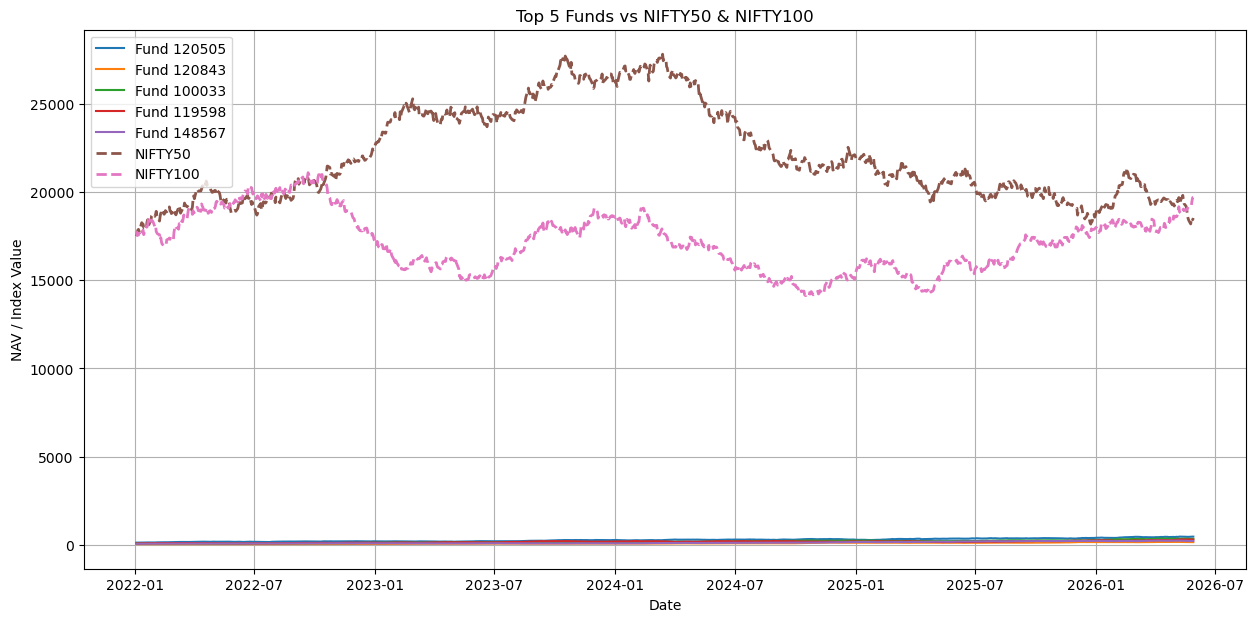

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,7))

# Plot Top 5 Funds

for fund in top5_codes:

    fund_data = top5_nav[
        top5_nav["amfi_code"] == fund
    ]

    plt.plot(
        fund_data["date"],
        fund_data["nav"],
        label=f"Fund {fund}"
    )

# Plot Benchmarks

for benchmark_name in ["NIFTY50", "NIFTY100"]:

    data = benchmark_compare[
        benchmark_compare["index_name"] == benchmark_name
    ]

    plt.plot(
        data["date"],
        data["close_value"],
        linewidth=2,
        linestyle="--",
        label=benchmark_name
    )

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100")
plt.xlabel("Date")
plt.ylabel("NAV / Index Value")
plt.legend()
plt.grid(True)

plt.show()

In [99]:
tracking_error_results = []

# Use benchmark returns already created earlier (NIFTY100)
benchmark_returns = benchmark[["date", "benchmark_return"]]

for fund in top5_codes:

    fund_data = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = fund_data.merge(
        benchmark_returns,
        on="date"
    )

    tracking_error = (
        (merged["daily_return"] - merged["benchmark_return"])
        .std()
        * np.sqrt(252)
    )

    tracking_error_results.append({
        "amfi_code": fund,
        "Tracking Error": tracking_error
    })

tracking_error_df = pd.DataFrame(tracking_error_results)

tracking_error_df

,amfi_code,Tracking Error
0,120505,0.231968
1,120843,0.206425
2,100033,0.228699
3,119598,0.283881
4,148567,0.189664


In [100]:
tracking_error_df.to_csv(
    "reports/tracking_error.csv",
    index=False
)

print("Benchmark Comparison Completed Successfully!")

Benchmark Comparison Completed Successfully!
